# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten, SimpleRNN
from keras.models import Sequential
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split

### 1.1 Generating dataset

In [ ]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [3]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [ ]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [ ]:
no_training_epochs = 5

### 1.3 Data examination

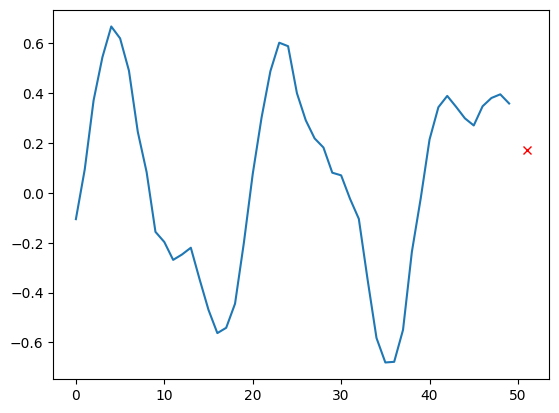

In [6]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [7]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [9]:
model_linear.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5


219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1829 - mean_squared_error: 0.1829 - val_loss: 0.0745 - val_mean_squared_error: 0.0745
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0491 - mean_squared_error: 0.0491 - val_loss: 0.0345 - val_mean_squared_error: 0.0345
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0274 - mean_squared_error: 0.0274 - val_loss: 0.0215 - val_mean_squared_error: 0.0215
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0188 - mean_squared_error: 0.0188 - val_loss: 0.0155 - val_mean_squared_error: 0.0155
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0145 - mean_squared_error: 0.0145 - val_loss: 0.0124 - val_mean_squared_error: 0.0124


In [11]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

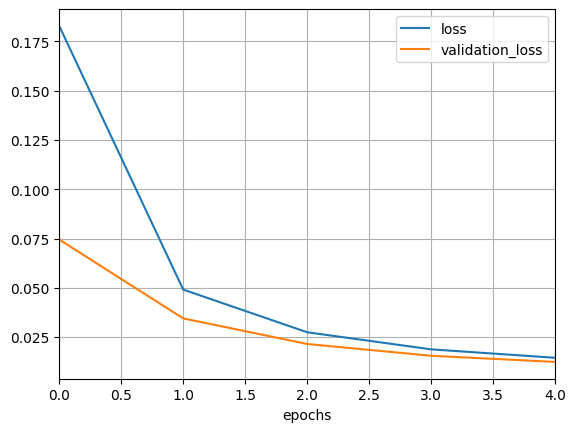

In [12]:
plot_function(history_linear)

In [13]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.012456895783543587
Test MSE:  0.012456895783543587


### 1.5 Simple RNN Model

In [14]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [16]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.1388 - mean_squared_error: 0.1388 - val_loss: 0.1258 - val_mean_squared_error: 0.1258
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1112 - mean_squared_error: 0.1112 - val_loss: 0.0953 - val_mean_squared_error: 0.0953
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0842 - mean_squared_error: 0.0842 - val_loss: 0.0717 - val_mean_squared_error: 0.0717
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0625 - mean_squared_error: 0.0625 - val_loss: 0.0518 - val_mean_squared_error: 0.0518
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0444 - mean_squared_error: 0.0444 - val_loss: 0.0357 - val_mean_squared_error: 0.0357


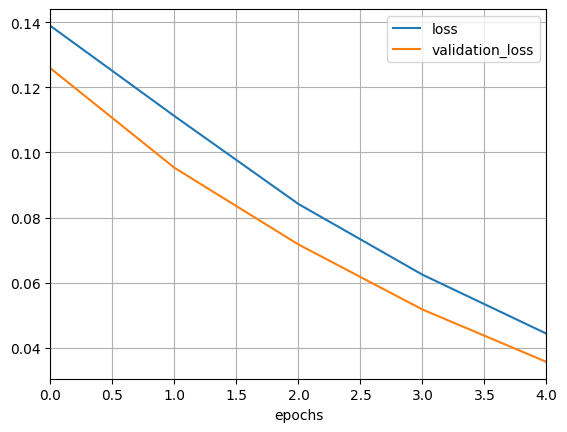

In [17]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [18]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [19]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [20]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0246 - mean_squared_error: 0.0246 - val_loss: 0.0058 - val_mean_squared_error: 0.0058
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0036 - val_mean_squared_error: 0.0036
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0034 - mean_squared_error: 0.0034 - val_loss: 0.0031 - val_mean_squared_error: 0.0031
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0031 - mean_squared_error: 0.0031 - val_loss: 0.0030 - val_mean_squared_error: 0.0030
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0030 - mean_squared_error: 0.0030 - val_loss: 0.0029 - val_mean_squared_error: 0.0029


In [21]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.0031972797587513924
Test MSE:  0.0031972797587513924


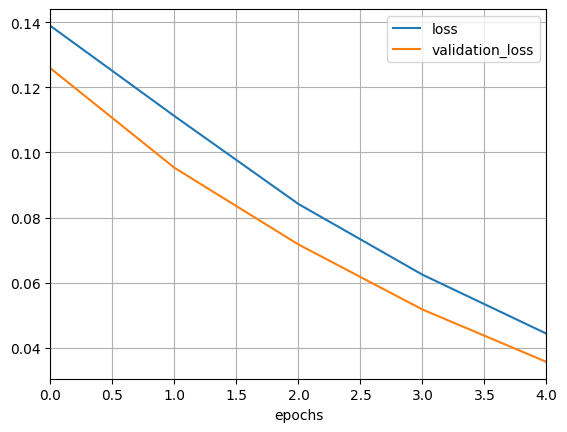

In [22]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [ ]:
import keras
from keras.layers import LSTM, Embedding, GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

### 2.1 - Load dataset

In [24]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 2.2 - Dataset examination

In [25]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [27]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shou

In [28]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [58]:
embed_size = 128
vocabulary_size = 1000
# Ensure embedding input_dim covers all token ids present in the data
vocabulary_size = int(max(X_train.max(), X_test.max())) + 1

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [59]:
optimizer = Adam(learning_rate = 0.001)

In [60]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [61]:


history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.5074 - loss: 0.7002 - val_accuracy: 0.5032 - val_loss: 0.6933
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.5085 - loss: 0.6996 - val_accuracy: 0.4938 - val_loss: 0.6933
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.4977 - loss: 0.6961 - val_accuracy: 0.5062 - val_loss: 0.6952
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.4997 - loss: 0.6952 - val_accuracy: 0.4938 - val_loss: 0.6941
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.5016 - loss: 0.6956 - val_accuracy: 0.5062 - val_loss: 0.6970


In [33]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.8919553756713867
Test accuracy:  52.81999707221985 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

## LTSM

In [63]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

vocabulary_size = 1000
embed_size = 128

model_ltsm = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
    
    
    keras.layers.LSTM(128, return_sequences=True),
    
   
    keras.layers.Dropout(0.2), 
    
    
    keras.layers.LSTM(64),
    
    # Standard dropout applied after the second LSTM
    keras.layers.Dropout(0.1),
    
    keras.layers.Dense(1, activation='sigmoid')
])

model_ltsm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# ==========================================
# Early Stopping 
# ==========================================
early_stopping = EarlyStopping(
    monitor='val_accuracy',         
    patience=3,                 
    restore_best_weights=True,  
    verbose=1                   
)

# Train the Model
ltsm_history = model_ltsm.fit(
    X_train, 
    y_train, 
    epochs=20, 
    validation_split=0.2, 
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5681 - loss: 0.6798 - val_accuracy: 0.6068 - val_loss: 0.6615
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5684 - loss: 0.6733 - val_accuracy: 0.6392 - val_loss: 0.6529
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6368 - loss: 0.6388 - val_accuracy: 0.5886 - val_loss: 0.6750
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6230 - loss: 0.6510 - val_accuracy: 0.7166 - val_loss: 0.5743
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7468 - loss: 0.5233 - val_accuracy: 0.7768 - val_loss: 0.4784
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8094 - loss: 0.4205 - val_accuracy: 0.8162 - val_loss: 0.4135
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8270 - loss: 0.3844 - val_accuracy: 0.8196 - val_loss: 0.4021
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8385 - loss: 0.3626 - val_accu

In [69]:
score_ltsm = model_ltsm.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score_ltsm[0])
print(f'Test accuracy: {score_ltsm[1]*100:.2f}%')

Test loss: 0.3858686685562134
Test accuracy: 82.89%


## GRU

In [55]:
# ==========================================
# 2. GRU Model
# ==========================================
gru_model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.GRU(64),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(1, activation='sigmoid')
])

gru_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print("GRU Model Built.")

early_stopping = EarlyStopping(
    monitor='val_accuracy',         
    patience=3,                 
    restore_best_weights=True,  
    verbose=1                   
)

# Train the Model
gru_history = gru_model.fit(
    X_train, 
    y_train, 
    epochs=20, 
    validation_split=0.2, 
    batch_size=64,
    callbacks=[early_stopping]
)


GRU Model Built.
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5509 - loss: 0.6904 - val_accuracy: 0.6384 - val_loss: 0.6476
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6442 - loss: 0.6217 - val_accuracy: 0.7628 - val_loss: 0.5028
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7789 - loss: 0.4726 - val_accuracy: 0.7818 - val_loss: 0.4684
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8189 - loss: 0.4029 - val_accuracy: 0.8188 - val_loss: 0.4072
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8349 - loss: 0.3708 - val_accuracy: 0.8308 - val_loss: 0.3837
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8501 - loss: 0.3461 - val_accuracy: 0.8364 - val_loss: 0.3764
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8556 - loss: 0.3310 - val_accuracy: 0.8324 - val_loss: 0.3754
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8616 - loss: 0.3184 - val_accuracy: 0.831

In [70]:
score_gru = gru_model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score_gru[0])
print(f'Test accuracy: {score_gru[1]*100:.2f}%')

Test loss: 0.3677578568458557
Test accuracy: 83.54%


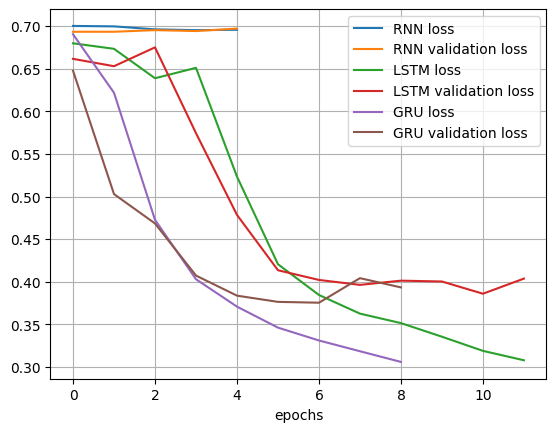

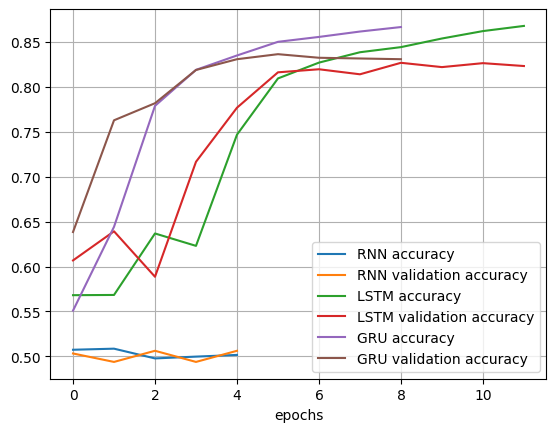

In [66]:
#plots all the training history from RNN, LTSM and GRU models
plt.figure()
plt.plot(history.history['loss'], label='RNN loss')
plt.plot(history.history['val_loss'], label='RNN validation loss')
plt.plot(ltsm_history.history['loss'], label='LSTM loss')
plt.plot(ltsm_history.history['val_loss'], label='LSTM validation loss')
plt.plot(gru_history.history['loss'], label='GRU loss')
plt.plot(gru_history.history['val_loss'], label='GRU validation loss')



plt.legend()
plt.grid()
plt.xlabel('epochs')
plt.show()

# accuracy plot
plt.figure()
plt.plot(history.history['accuracy'], label='RNN accuracy')
plt.plot(history.history['val_accuracy'], label='RNN validation accuracy')
plt.plot(ltsm_history.history['accuracy'], label='LSTM accuracy')
plt.plot(ltsm_history.history['val_accuracy'], label='LSTM validation accuracy')
plt.plot(gru_history.history['accuracy'], label='GRU accuracy')
plt.plot(gru_history.history['val_accuracy'], label='GRU validation accuracy')
plt.legend()
plt.grid()
plt.xlabel('epochs')
plt.show()

In [71]:
# print all test scores
print("Simple RNN Test Loss:", score[0])
print("Simple RNN Test Accuracy:", score[1]*100, "%")
print("LSTM Test Loss:", score_ltsm[0])
print("LSTM Test Accuracy:", score_ltsm[1]*100, "%")
print("GRU Test Loss:", score_gru[0])
print("GRU Test Accuracy:", score_gru[1]*100, "%")

Simple RNN Test Loss: 0.3858686685562134
Simple RNN Test Accuracy: 82.89200067520142 %
LSTM Test Loss: 0.3858686685562134
LSTM Test Accuracy: 82.89200067520142 %
GRU Test Loss: 0.3677578568458557
GRU Test Accuracy: 83.53599905967712 %
